# Enhanced Voicegram-Based Dysarthric Command Recognition

## One-file project notebook

This notebook implements a complete project pipeline inspired by the paper **“Speech Vision: An End-to-End Deep Learning-Based Dysarthric Automatic Speech Recognition System.”**

The original paper converted dysarthric speech into visual acoustic representations called **voicegrams** and then used a two-dimensional convolutional neural network to classify isolated words. In this project, we keep the same core idea but use an accessible dataset and improve the model architecture.

### Project research gap

The selected paper reports that the original Spatial Convolutional Neural Network architecture can be improved because it may suffer from vanishing gradients and representational bottlenecks. This notebook investigates that gap by comparing:

1. **Baseline Convolutional Neural Network** — a simple voicegram/spectrogram image classifier.
2. **Proposed Residual-Attention Convolutional Neural Network** — a stronger model using residual connections and attention blocks.

### Dataset used

We use the **EasyCall Dysarthria Dataset** from Hugging Face: `changelinglab/easycall-dysarthria`.

EasyCall is a dysarthric command-speech corpus. It is suitable for this project because the task is command/word classification, which matches the isolated-word recognition style of the selected paper.

### Complete architecture

```text
EasyCall audio commands
        ↓
Audio preprocessing
        ↓
Voicegram-like Mel-spectrogram image generation
        ↓
Data augmentation
        ↓
Baseline CNN training
        ↓
Residual-Attention CNN training
        ↓
Metrics, graphs, confusion matrix, and prediction demo
```

### What this notebook contains

- Dataset loading/downloading from Hugging Face
- Fallback toy dataset generator if internet or dataset loading fails
- Audio preprocessing
- Voicegram-like Mel-spectrogram generation
- Exploratory dataset analysis
- Baseline CNN model
- Proposed Residual-Attention CNN model
- Training loop
- Accuracy, Precision, Recall, F1-score, Word Recognition Accuracy
- Confusion matrix
- Training/validation graphs
- Final comparison table
- Single-audio prediction function

## 1. Install required packages

Run this cell first. It installs missing packages only when needed.

> In Google Colab, Kaggle, or a local Jupyter environment, this may take a few minutes the first time.

In [23]:
import sys
import subprocess
import importlib.util

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "torch": "torch",
    "librosa": "librosa",
    "soundfile": "soundfile",
    "PIL": "pillow",
    "datasets": "datasets[audio]",
    "tqdm": "tqdm",
}

missing = []
for import_name, pip_name in REQUIRED_PACKAGES.items():
    if importlib.util.find_spec(import_name) is None:
        missing.append(pip_name)

if missing:
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("All required packages are already installed.")

All required packages are already installed.


## 2. Imports, configuration, and reproducibility

Change the values in this cell depending on your computer power.

Recommended starting settings:

- `MAX_CLASSES = 10`
- `MAX_SAMPLES_PER_CLASS = 80`
- `EPOCHS = 12`

For faster testing, reduce the numbers. For final results, increase them.

In [24]:
import os
import re
import math
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import librosa
import matplotlib.cm as cm

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    confusion_matrix,
    classification_report,
)

warnings.filterwarnings("ignore")

# -----------------------------
# Main project configuration
# -----------------------------
SEED = 42
DATASET_NAME = "changelinglab/easycall-dysarthria"

# If True, the notebook skips Hugging Face and creates a small synthetic dataset.
# Keep this False for the real project.
USE_TOY_DATASET = False

# If EasyCall download fails, the notebook automatically creates a toy dataset
# so that the whole code can still be tested end-to-end.
FALLBACK_TO_TOY_DATASET = False

# Dataset size control
MAX_CLASSES = 10
MAX_SAMPLES_PER_CLASS = 120
DYSARTHRIC_ONLY = False

# Better sampling for final project
BALANCED_EASYCALL_SAMPLING = True
SPEAKER_INDEPENDENT_SPLIT = True

# Audio and spectrogram settings
TARGET_SAMPLE_RATE = 16000
N_MELS = 128
IMAGE_SIZE = 150
N_FFT = 1024
HOP_LENGTH = 256

# Training settings
BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 8
NUM_WORKERS = 0

# Workspace folders
WORK_DIR = Path("easycall_voicegram_project_workspace")
RAW_AUDIO_DIR = WORK_DIR / "raw_audio"
SPECTROGRAM_DIR = WORK_DIR / "spectrogram_arrays"
RESULTS_DIR = WORK_DIR / "results"
MODELS_DIR = RESULTS_DIR / "models"
GRAPHS_DIR = RESULTS_DIR / "graphs"

for folder in [WORK_DIR, RAW_AUDIO_DIR, SPECTROGRAM_DIR, RESULTS_DIR, MODELS_DIR, GRAPHS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)


import shutil

RESET_WORKSPACE_FOR_REAL_EASYCALL = True

if RESET_WORKSPACE_FOR_REAL_EASYCALL:
    for folder in [RAW_AUDIO_DIR, SPECTROGRAM_DIR]:
        if folder.exists():
            shutil.rmtree(folder)
        folder.mkdir(parents=True, exist_ok=True)

    print("Old toy/raw audio and spectrogram cache cleared.")


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("Workspace:", WORK_DIR.resolve())

Old toy/raw audio and spectrogram cache cleared.
Device: cuda
Workspace: /teamspace/studios/this_studio/Speech_NLP_Project/easycall_voicegram_project_workspace


## 3. Utility functions

These helper functions keep the notebook clean.

They handle label cleaning, audio normalization, automatic dataset-column detection, and path management.

In [25]:
def sanitize_label(value):
    """Convert labels such as 'Apri Contatti' into clean folder-safe labels."""
    value = str(value).strip().lower()
    value = re.sub(r"[^a-zA-Z0-9_\-]+", "_", value)
    value = re.sub(r"_+", "_", value).strip("_")
    return value if value else "unknown"


def normalize_audio(y):
    """Convert audio to mono float32 and normalize amplitude safely."""
    y = np.asarray(y, dtype=np.float32)
    if y.ndim > 1:
        y = y.mean(axis=1)
    if len(y) == 0:
        y = np.zeros(TARGET_SAMPLE_RATE // 2, dtype=np.float32)
    max_val = np.max(np.abs(y))
    if max_val > 1e-8:
        y = y / max_val
    return y.astype(np.float32)


def trim_and_prepare_audio(y, sr, target_sr=TARGET_SAMPLE_RATE):
    """Resample, trim silence, normalize, and ensure a minimum duration."""
    y = normalize_audio(y)
    if sr != target_sr:
        y = librosa.resample(y, orig_sr=sr, target_sr=target_sr)
    y, _ = librosa.effects.trim(y, top_db=30)
    y = normalize_audio(y)
    min_len = int(0.30 * target_sr)
    if len(y) < min_len:
        y = np.pad(y, (0, min_len - len(y)))
    return y.astype(np.float32), target_sr


def detect_audio_column(dataset_split):
    """Try to find the audio column in a Hugging Face dataset split."""
    columns = list(dataset_split.column_names)
    preferred = ["audio", "file", "wav", "speech", "path"]
    lower_map = {c.lower(): c for c in columns}

    for name in preferred:
        if name in lower_map:
            return lower_map[name]

    for col in columns:
        lc = col.lower()
        if any(name in lc for name in preferred):
            return col

    first = dataset_split[0]
    for col, value in first.items():
        if isinstance(value, dict) and any(k in value for k in ["array", "path", "bytes", "sampling_rate"]):
            return col

    raise ValueError(f"Could not detect audio column. Available columns: {columns}")


def detect_label_column(dataset_split, audio_col):
    """Try to find the command/text label column."""
    columns = list(dataset_split.column_names)
    preferred = [
        "transcription", "transcript", "sentence", "text", "label",
        "command", "word", "phrase", "prompt", "target",
    ]
    lower_map = {c.lower(): c for c in columns}

    for name in preferred:
        if name in lower_map and lower_map[name] != audio_col:
            return lower_map[name]

    for col in columns:
        if col == audio_col:
            continue
        lc = col.lower()
        if any(name in lc for name in preferred):
            return col

    first = dataset_split[0]
    for col, value in first.items():
        if col == audio_col:
            continue
        if isinstance(value, str) and value.strip():
            return col

    raise ValueError(f"Could not detect label column. Available columns: {columns}")


def detect_optional_column(dataset_split, candidates):
    columns = list(dataset_split.column_names)
    lower_map = {c.lower(): c for c in columns}
    for name in candidates:
        if name in lower_map:
            return lower_map[name]
    for col in columns:
        lc = col.lower()
        if any(name in lc for name in candidates):
            return col
    return None


def row_to_audio(row, audio_col):
    """Convert a Hugging Face row audio value into (audio_array, sampling_rate)."""
    value = row[audio_col]

    if isinstance(value, dict):
        if value.get("array") is not None:
            y = np.asarray(value["array"], dtype=np.float32)
            sr = int(value.get("sampling_rate") or TARGET_SAMPLE_RATE)
            return y, sr
        if value.get("bytes") is not None:
            import io
            y, sr = sf.read(io.BytesIO(value["bytes"]), dtype="float32")
            return y, int(sr)
        if value.get("path") is not None:
            y, sr = sf.read(value["path"], dtype="float32")
            return y, int(sr)

    if isinstance(value, (str, Path)):
        y, sr = sf.read(value, dtype="float32")
        return y, int(sr)

    raise ValueError(f"Unsupported audio value type: {type(value)}")

def row_to_audio_no_torchcodec(row, audio_col):
    """
    Read EasyCall audio without using Hugging Face TorchCodec decoding.

    This is required because the notebook failed at Audio(decode=True)
    due to TorchCodec / FFmpeg / PyTorch mismatch.
    """
    import io

    value = row[audio_col]

    if isinstance(value, dict):
        audio_bytes = value.get("bytes", None)
        audio_path = value.get("path", None)

        if audio_bytes is not None:
            y, sr = sf.read(io.BytesIO(audio_bytes), dtype="float32")
            return y, int(sr)

        if audio_path is not None and Path(audio_path).exists():
            y, sr = sf.read(audio_path, dtype="float32")
            return y, int(sr)

        raise ValueError(f"Audio dict has no readable bytes/path. Keys: {value.keys()}")

    if isinstance(value, (str, Path)):
        y, sr = sf.read(str(value), dtype="float32")
        return y, int(sr)

    raise ValueError(f"Unsupported audio value type: {type(value)}")

def maybe_is_dysarthric(row, severity_col):
    """Best-effort detection of dysarthric/control rows from metadata."""
    if severity_col is None or severity_col not in row:
        return None

    value = row[severity_col]
    text = str(value).strip().lower()

    if text in {"control", "healthy", "normal", "hc", "non_dysarthric", "non-dysarthric"}:
        return False
    if text in {"dysarthric", "patient", "impaired", "pathological", "dys"}:
        return True

    try:
        number = float(value)
        if math.isfinite(number):
            return number > 0
    except Exception:
        pass

    return None

## 4. Dataset loading

This cell tries to download and export a subset of EasyCall from Hugging Face.

If the dataset cannot be loaded because of internet issues, missing permissions, or environment limitations, the notebook automatically creates a small toy audio dataset. This fallback is only for testing the code. For final project results, use the real EasyCall dataset.

In [26]:
def create_toy_dataset(
    output_dir=RAW_AUDIO_DIR,
    max_classes=4,
    samples_per_class=40,
    target_sr=TARGET_SAMPLE_RATE,
    seed=SEED,
):
    """
    Toy fallback dataset.

    IMPORTANT:
    This is only for testing the pipeline.
    Final project results should use EasyCall, not this toy dataset.
    """
    seed_everything(seed)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    base_commands = [
        "apri_contatti", "chiama", "fine_chiamata", "messaggio",
        "rubrica", "sezione", "volume_su", "volume_giu",
    ]
    commands = base_commands[:max_classes]
    rows = []

    duration = 0.85
    t = np.linspace(0, duration, int(target_sr * duration), endpoint=False)

    for class_idx, label in enumerate(commands):
        base_freq = 220 + class_idx * 80

        for sample_idx in range(samples_per_class):
            freq_shift = np.random.uniform(-12, 12)
            speed = np.random.uniform(0.92, 1.08)
            amp = np.random.uniform(0.55, 0.95)

            y = amp * np.sin(2 * np.pi * (base_freq + freq_shift) * t)
            y += 0.35 * amp * np.sin(2 * np.pi * (base_freq * 1.7 + freq_shift) * t)
            y *= np.hanning(len(y))
            y += np.random.normal(0, 0.015, size=len(y))

            if speed != 1.0:
                new_len = max(100, int(len(y) / speed))
                y = np.interp(
                    np.linspace(0, len(y) - 1, new_len),
                    np.arange(len(y)),
                    y,
                ).astype(np.float32)

            y, sr = trim_and_prepare_audio(y, target_sr, target_sr)

            wav_dir = output_dir / label
            wav_dir.mkdir(parents=True, exist_ok=True)

            wav_path = wav_dir / f"toy_{label}_{sample_idx:04d}.wav"
            sf.write(wav_path, y, sr)

            rows.append({
                "audio_path": str(wav_path),
                "label": label,
                "raw_label": label,
                "speaker_id": f"toy_speaker_{sample_idx % 6}",
                "severity": "toy",
                "is_dysarthric_detected": None,
                "source_dataset": "toy_synthetic_dataset",
            })

    metadata = pd.DataFrame(rows)
    metadata_path = output_dir / "metadata.csv"
    metadata.to_csv(metadata_path, index=False)

    print(f"Toy dataset created: {metadata_path}")
    return metadata


def normalize_severity_value(value):
    """
    Convert severity values into clean strings.
    EasyCall usually has numeric severity values such as 0, 1, 2, etc.
    """
    if value is None:
        return "unknown"

    text = str(value).strip()

    if text == "":
        return "unknown"

    try:
        number = float(text)
        if number.is_integer():
            return str(int(number))
        return str(number)
    except Exception:
        return sanitize_label(text)


def build_easycall_candidate_table(
    dataset_split,
    label_col,
    speaker_col,
    severity_col,
    dysarthric_only=False,
):
    """
    Build a metadata-only candidate table.

    This does not decode audio, so it avoids the TorchCodec problem.
    """
    candidate_rows = []

    for idx, row in enumerate(tqdm(dataset_split, desc="Scanning EasyCall metadata")):
        label = sanitize_label(row[label_col])

        if not label:
            continue

        speaker_id = str(row.get(speaker_col, "unknown_speaker")) if speaker_col else "unknown_speaker"
        severity = normalize_severity_value(row.get(severity_col, "unknown")) if severity_col else "unknown"
        is_dys = maybe_is_dysarthric(row, severity_col)

        if dysarthric_only and is_dys is not True:
            continue

        candidate_rows.append({
            "dataset_index": idx,
            "label": label,
            "raw_label": str(row[label_col]),
            "speaker_id": speaker_id,
            "severity": severity,
            "is_dysarthric_detected": is_dys,
        })

    candidate_df = pd.DataFrame(candidate_rows)

    if candidate_df.empty:
        raise RuntimeError("No candidate rows found in EasyCall metadata.")

    return candidate_df


def round_robin_select_indices(
    candidates,
    max_samples,
    group_cols=("severity", "speaker_id"),
    seed=SEED,
):
    """
    Select samples in a balanced way across severity and speaker.

    Earlier code selected the first N samples per class.
    This function avoids that by rotating through severity-speaker groups.
    """
    rng = np.random.default_rng(seed)

    candidates = candidates.copy()
    candidates["_random_order"] = rng.random(len(candidates))

    grouped_indices = []

    for _, group in candidates.groupby(list(group_cols), dropna=False):
        indices = group.sort_values("_random_order")["dataset_index"].tolist()
        if indices:
            grouped_indices.append(indices)

    rng.shuffle(grouped_indices)

    selected = []
    keep_going = True

    while keep_going and len(selected) < max_samples:
        keep_going = False

        for indices in grouped_indices:
            if indices and len(selected) < max_samples:
                selected.append(indices.pop(0))
                keep_going = True

    return selected


def select_balanced_easycall_indices(
    candidate_df,
    max_classes=MAX_CLASSES,
    max_samples_per_class=MAX_SAMPLES_PER_CLASS,
    seed=SEED,
):
    """
    Select top command classes, but sample them in a speaker/severity-balanced way.
    """
    label_counts = candidate_df["label"].value_counts()

    selected_labels = label_counts.head(max_classes).index.tolist()

    print("Selected labels:")
    for label in selected_labels:
        print(f"  {label}: available={label_counts[label]}")

    selected_frames = []

    for class_rank, label in enumerate(selected_labels):
        class_candidates = candidate_df[candidate_df["label"] == label].copy()

        selected_indices = round_robin_select_indices(
            class_candidates,
            max_samples=max_samples_per_class,
            group_cols=("severity", "speaker_id"),
            seed=seed + class_rank,
        )

        selected_class_df = class_candidates[class_candidates["dataset_index"].isin(selected_indices)].copy()

        selected_frames.append(selected_class_df)

    selected_df = pd.concat(selected_frames, ignore_index=True)

    selected_df = selected_df.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    print("\nBalanced selected subset:")
    print("Total selected rows:", len(selected_df))
    print("\nClass distribution:")
    print(selected_df["label"].value_counts())

    print("\nSeverity distribution:")
    print(selected_df["severity"].value_counts())

    print("\nUnique speakers:", selected_df["speaker_id"].nunique())

    return selected_df


def load_easycall_subset(
    dataset_name=DATASET_NAME,
    output_dir=RAW_AUDIO_DIR,
    max_classes=MAX_CLASSES,
    max_samples_per_class=MAX_SAMPLES_PER_CLASS,
    dysarthric_only=DYSARTHRIC_ONLY,
    target_sr=TARGET_SAMPLE_RATE,
):
    """
    Download/export a real EasyCall subset into local WAV files and metadata.

    Important:
    This uses Audio(decode=False) and manual soundfile reading.
    This avoids the TorchCodec / FFmpeg failure.
    """
    from datasets import load_dataset, Audio, DatasetDict, concatenate_datasets

    output_dir = Path(output_dir)
    audio_output_dir = output_dir / "audio"
    audio_output_dir.mkdir(parents=True, exist_ok=True)

    print(f"Loading Hugging Face dataset: {dataset_name}")

    dataset_obj = load_dataset(dataset_name)

    if isinstance(dataset_obj, DatasetDict):
        split_names = list(dataset_obj.keys())
        print("Available splits:", split_names)

        split_datasets = [dataset_obj[name] for name in split_names]

        if len(split_datasets) > 1:
            dataset_split = concatenate_datasets(split_datasets)
        else:
            dataset_split = split_datasets[0]
    else:
        dataset_split = dataset_obj

    print("Total rows before filtering:", len(dataset_split))
    print("Columns:", dataset_split.column_names)

    audio_col = detect_audio_column(dataset_split)
    label_col = detect_label_column(dataset_split, audio_col)

    speaker_col = detect_optional_column(
        dataset_split,
        ["speaker_id", "speaker", "spk", "subject", "patient"],
    )

    severity_col = detect_optional_column(
        dataset_split,
        ["tom", "therapy", "severity", "dysarthria", "status", "class", "group", "impairment"],
    )

    print("Detected audio column   :", audio_col)
    print("Detected label column   :", label_col)
    print("Detected speaker column :", speaker_col)
    print("Detected severity column:", severity_col)

    # Critical fix: do not decode through TorchCodec.
    dataset_split = dataset_split.cast_column(audio_col, Audio(decode=False))

    candidate_df = build_easycall_candidate_table(
        dataset_split=dataset_split,
        label_col=label_col,
        speaker_col=speaker_col,
        severity_col=severity_col,
        dysarthric_only=dysarthric_only,
    )

    if BALANCED_EASYCALL_SAMPLING:
        selected_df = select_balanced_easycall_indices(
            candidate_df,
            max_classes=max_classes,
            max_samples_per_class=max_samples_per_class,
            seed=SEED,
        )
    else:
        selected_labels = candidate_df["label"].value_counts().head(max_classes).index.tolist()
        selected_df = (
            candidate_df[candidate_df["label"].isin(selected_labels)]
            .groupby("label", group_keys=False)
            .head(max_samples_per_class)
            .reset_index(drop=True)
        )

    rows = []
    per_class_counter = Counter()
    skipped_audio = 0

    for _, info in tqdm(
        selected_df.iterrows(),
        total=len(selected_df),
        desc="Exporting balanced EasyCall audio",
    ):
        dataset_index = int(info["dataset_index"])
        row = dataset_split[dataset_index]

        label = info["label"]
        speaker_id = str(info["speaker_id"])
        severity = str(info["severity"])
        is_dys = info["is_dysarthric_detected"]

        try:
            y, sr = row_to_audio_no_torchcodec(row, audio_col)
            y, sr = trim_and_prepare_audio(y, sr, target_sr)
        except Exception as exc:
            skipped_audio += 1
            if skipped_audio <= 10:
                print(f"Skipping dataset row {dataset_index} because audio could not be read: {exc}")
            continue

        wav_dir = audio_output_dir / label
        wav_dir.mkdir(parents=True, exist_ok=True)

        safe_speaker = sanitize_label(speaker_id)
        count = per_class_counter[label]

        wav_path = wav_dir / f"easycall_{safe_speaker}_{label}_{count:05d}.wav"
        sf.write(wav_path, y, sr)

        rows.append({
            "audio_path": str(wav_path),
            "label": label,
            "raw_label": str(info["raw_label"]),
            "speaker_id": speaker_id,
            "severity": severity,
            "is_dysarthric_detected": is_dys,
            "source_dataset": dataset_name,
        })

        per_class_counter[label] += 1

    metadata = pd.DataFrame(rows)

    if metadata.empty:
        raise RuntimeError(
            "No rows were exported from EasyCall. "
            "This means the audio could not be read. "
            "Check dataset download and soundfile support."
        )

    metadata_path = output_dir / "metadata.csv"
    metadata.to_csv(metadata_path, index=False)

    print("\nExport completed.")
    print("Exported metadata saved at:", metadata_path)
    print("Exported samples:", len(metadata))
    print("Skipped audio rows:", skipped_audio)

    print("\nFinal class distribution:")
    print(metadata["label"].value_counts())

    print("\nFinal severity distribution:")
    print(metadata["severity"].value_counts())

    print("\nFinal unique speakers:", metadata["speaker_id"].nunique())

    print("\nSource dataset check:")
    print(metadata["source_dataset"].value_counts())

    return metadata


def get_project_metadata():
    """
    Main dataset entry point.

    For final project results:
    USE_TOY_DATASET must be False.
    FALLBACK_TO_TOY_DATASET must be False.
    """
    if USE_TOY_DATASET:
        print("USE_TOY_DATASET=True, so toy data is being created.")
        return create_toy_dataset(max_classes=min(MAX_CLASSES, 4), samples_per_class=40)

    try:
        metadata = load_easycall_subset()

        if not metadata["source_dataset"].eq(DATASET_NAME).all():
            raise RuntimeError("Metadata contains non-EasyCall rows.")

        print("\nReal EasyCall dataset loaded successfully.")
        return metadata

    except Exception as exc:
        print("\nEasyCall loading failed.")
        print("Reason:", repr(exc))

        if FALLBACK_TO_TOY_DATASET:
            print("\nCreating toy dataset so the notebook can still run end-to-end.")
            return create_toy_dataset(max_classes=min(MAX_CLASSES, 4), samples_per_class=40)

        raise


metadata = get_project_metadata()
metadata.head()

Loading Hugging Face dataset: changelinglab/easycall-dysarthria


Available splits: ['test', 'train', 'validation']
Total rows before filtering: 21386
Columns: ['audio', 'filename', 'speaker', 'text', 'dysarthria_severity']
Detected audio column   : audio
Detected label column   : text
Detected speaker column : speaker
Detected severity column: dysarthria_severity


Scanning EasyCall metadata:   0%|          | 0/21386 [00:00<?, ?it/s]

Selected labels:
  otto: available=318
  deseleziona: available=318
  nuovo_contatto: available=318
  sette: available=318
  aggiungi_ai_preferiti: available=317
  scesi: available=317
  chiama_emergenza: available=317
  no: available=317
  chiama_ultimo_numero: available=317
  uno: available=317

Balanced selected subset:
Total selected rows: 1200

Class distribution:
label
uno                      120
no                       120
otto                     120
sette                    120
nuovo_contatto           120
chiama_ultimo_numero     120
chiama_emergenza         120
deseleziona              120
aggiungi_ai_preferiti    120
scesi                    120
Name: count, dtype: int64

Severity distribution:
severity
0      529
1      352
2      169
3      128
n_a     22
Name: count, dtype: int64

Unique speakers: 55


Exporting balanced EasyCall audio:   0%|          | 0/1200 [00:00<?, ?it/s]


Export completed.
Exported metadata saved at: easycall_voicegram_project_workspace/raw_audio/metadata.csv
Exported samples: 1200
Skipped audio rows: 0

Final class distribution:
label
uno                      120
no                       120
otto                     120
sette                    120
nuovo_contatto           120
chiama_ultimo_numero     120
chiama_emergenza         120
deseleziona              120
aggiungi_ai_preferiti    120
scesi                    120
Name: count, dtype: int64

Final severity distribution:
severity
0      529
1      352
2      169
3      128
n_a     22
Name: count, dtype: int64

Final unique speakers: 55

Source dataset check:
source_dataset
changelinglab/easycall-dysarthria    1200
Name: count, dtype: int64

Real EasyCall dataset loaded successfully.


,audio_path,label,raw_label,speaker_id,severity,is_dysarthric_detected,source_dataset
0,easycall_voicegram_project_workspace/raw_audio...,uno,uno,m09,1,True,changelinglab/easycall-dysarthria
1,easycall_voicegram_project_workspace/raw_audio...,no,no,f06,1,True,changelinglab/easycall-dysarthria
2,easycall_voicegram_project_workspace/raw_audio...,otto,otto,m09,1,True,changelinglab/easycall-dysarthria
3,easycall_voicegram_project_workspace/raw_audio...,sette,sette,fc06,0,False,changelinglab/easycall-dysarthria
4,easycall_voicegram_project_workspace/raw_audio...,otto,otto,m02,1,True,changelinglab/easycall-dysarthria


## 5. Dataset exploration

This section shows the dataset size, number of command classes, and class distribution.

In [27]:
print("Total samples:", len(metadata))
print("Number of classes:", metadata["label"].nunique())
print("Source dataset values:")
print(metadata["source_dataset"].value_counts())

metadata.head(10)

Total samples: 1200
Number of classes: 10
Source dataset values:
source_dataset
changelinglab/easycall-dysarthria    1200
Name: count, dtype: int64


,audio_path,label,raw_label,speaker_id,severity,is_dysarthric_detected,source_dataset
0,easycall_voicegram_project_workspace/raw_audio...,uno,uno,m09,1,True,changelinglab/easycall-dysarthria
1,easycall_voicegram_project_workspace/raw_audio...,no,no,f06,1,True,changelinglab/easycall-dysarthria
2,easycall_voicegram_project_workspace/raw_audio...,otto,otto,m09,1,True,changelinglab/easycall-dysarthria
3,easycall_voicegram_project_workspace/raw_audio...,sette,sette,fc06,0,False,changelinglab/easycall-dysarthria
4,easycall_voicegram_project_workspace/raw_audio...,otto,otto,m02,1,True,changelinglab/easycall-dysarthria
5,easycall_voicegram_project_workspace/raw_audio...,uno,uno,m03,2,True,changelinglab/easycall-dysarthria
6,easycall_voicegram_project_workspace/raw_audio...,nuovo_contatto,nuovo contatto,mc09,0,False,changelinglab/easycall-dysarthria
7,easycall_voicegram_project_workspace/raw_audio...,chiama_ultimo_numero,chiama ultimo numero,fc07,0,False,changelinglab/easycall-dysarthria
8,easycall_voicegram_project_workspace/raw_audio...,sette,sette,m19,2,True,changelinglab/easycall-dysarthria
9,easycall_voicegram_project_workspace/raw_audio...,no,no,fc07,0,False,changelinglab/easycall-dysarthria


label
uno                      120
no                       120
otto                     120
sette                    120
nuovo_contatto           120
chiama_ultimo_numero     120
chiama_emergenza         120
deseleziona              120
aggiungi_ai_preferiti    120
scesi                    120
Name: count, dtype: int64


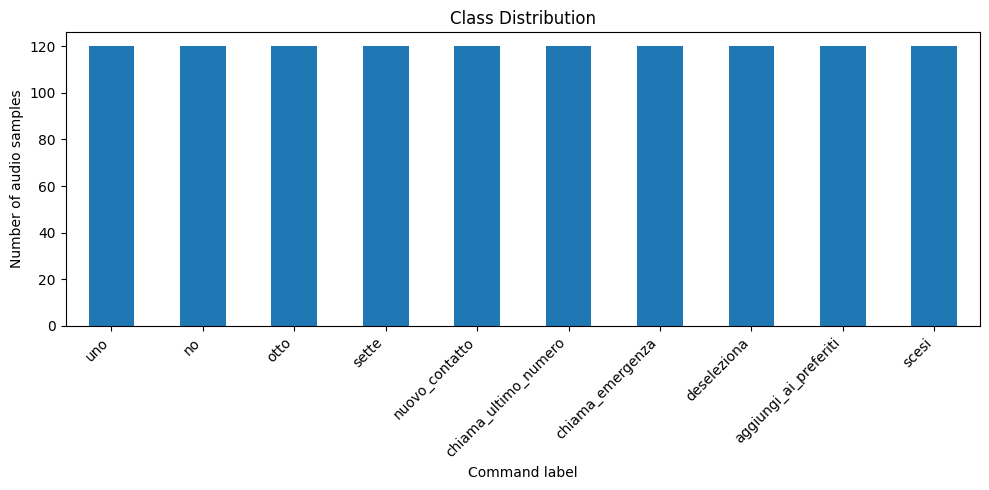

In [28]:
class_counts = metadata["label"].value_counts().sort_values(ascending=False)
print(class_counts)

plt.figure(figsize=(10, 5))
class_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Command label")
plt.ylabel("Number of audio samples")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Dataset quality checks
------------------------------------------------------------
Total samples: 1200
Unique command labels: 10
Unique speakers: 55

Class distribution:


,samples
label,
uno,120
no,120
otto,120
sette,120
nuovo_contatto,120
chiama_ultimo_numero,120
chiama_emergenza,120
deseleziona,120
aggiungi_ai_preferiti,120



Severity distribution:


,samples
severity,
0,529
1,352
2,169
3,128
n_a,22



Number of unique speakers per class:


,unique_speakers
label,
aggiungi_ai_preferiti,55
chiama_emergenza,55
chiama_ultimo_numero,55
deseleziona,55
no,55
nuovo_contatto,55
otto,55
scesi,55
sette,55



Class × severity table:


severity,0,1,2,3,n_a
label,,,,,
aggiungi_ai_preferiti,54,36,16,12,2
chiama_emergenza,51,35,17,15,2
chiama_ultimo_numero,53,35,17,13,2
deseleziona,53,35,16,13,3
no,53,34,18,13,2
nuovo_contatto,53,36,17,12,2
otto,54,34,17,13,2
scesi,55,34,17,12,2
sette,52,36,17,13,2


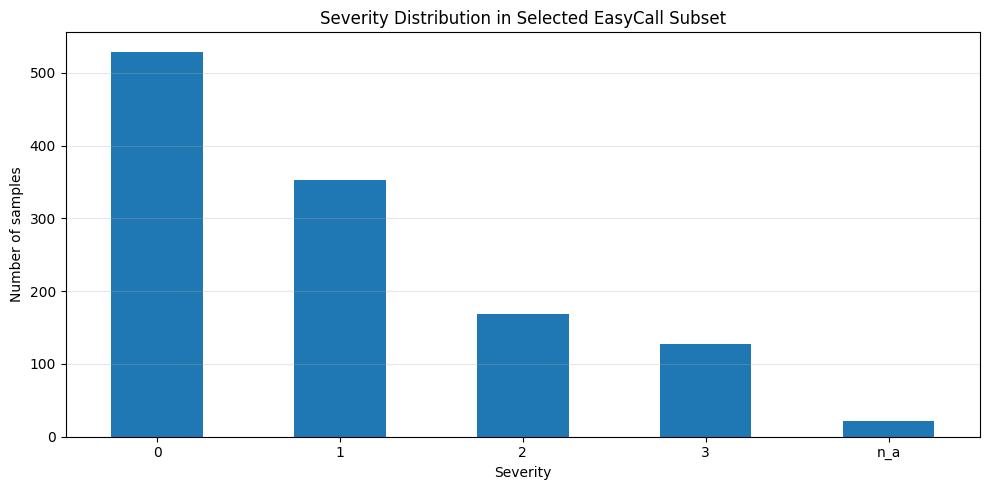

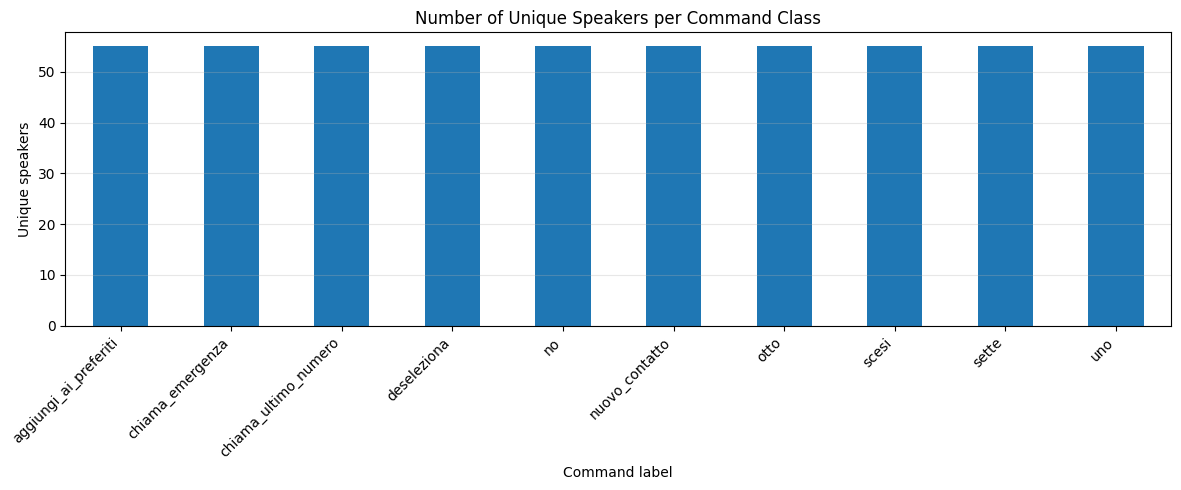

In [29]:
print("Dataset quality checks")
print("-" * 60)

print("Total samples:", len(metadata))
print("Unique command labels:", metadata["label"].nunique())
print("Unique speakers:", metadata["speaker_id"].nunique())

print("\nClass distribution:")
display(metadata["label"].value_counts().to_frame("samples"))

print("\nSeverity distribution:")
display(metadata["severity"].value_counts().to_frame("samples"))

print("\nNumber of unique speakers per class:")
speakers_per_class = metadata.groupby("label")["speaker_id"].nunique().sort_values(ascending=False)
display(speakers_per_class.to_frame("unique_speakers"))

print("\nClass × severity table:")
class_severity_table = pd.crosstab(metadata["label"], metadata["severity"])
display(class_severity_table)

plt.figure(figsize=(10, 5))
metadata["severity"].value_counts().sort_index().plot(kind="bar")
plt.title("Severity Distribution in Selected EasyCall Subset")
plt.xlabel("Severity")
plt.ylabel("Number of samples")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
speakers_per_class.plot(kind="bar")
plt.title("Number of Unique Speakers per Command Class")
plt.xlabel("Command label")
plt.ylabel("Unique speakers")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Listen to one sample and visualize waveform

This helps us confirm that the audio files are being loaded correctly.

Sample label: uno
Sample path: easycall_voicegram_project_workspace/raw_audio/audio/uno/easycall_m09_uno_00000.wav


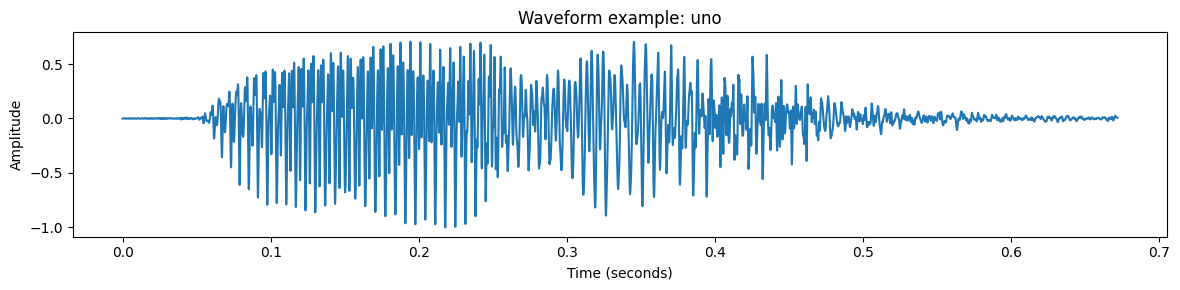

In [30]:
# Select one example audio file
sample_row = metadata.iloc[0]
sample_audio_path = sample_row["audio_path"]
print("Sample label:", sample_row["label"])
print("Sample path:", sample_audio_path)

sample_y, sample_sr = librosa.load(sample_audio_path, sr=TARGET_SAMPLE_RATE, mono=True)

plt.figure(figsize=(12, 3))
plt.plot(np.arange(len(sample_y)) / TARGET_SAMPLE_RATE, sample_y)
plt.title(f"Waveform example: {sample_row['label']}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

# In Jupyter/Colab this displays an audio player.
try:
    from IPython.display import Audio, display
    display(Audio(sample_y, rate=TARGET_SAMPLE_RATE))
except Exception:
    print("Audio display not available in this environment.")

## 7. Voicegram-like Mel-spectrogram generation

The selected paper used visual representations of speech called **voicegrams**. Here we implement a voicegram-like representation using a Mel-spectrogram heatmap.

The flow is:

```text
Audio waveform → Mel-spectrogram → decibel scale → normalized heatmap → resized RGB image
```

This transforms the speech-recognition problem into an image-classification problem.

Voicegram shape: (150, 150, 3)


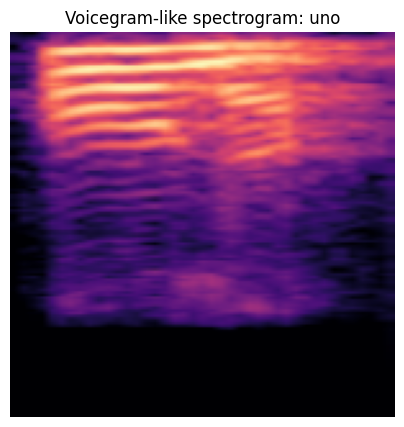

In [31]:
def audio_to_voicegram_array(
    audio_path,
    target_sr=TARGET_SAMPLE_RATE,
    n_mels=N_MELS,
    image_size=IMAGE_SIZE,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    cmap_name="magma",
):
    """Convert an audio file into an RGB voicegram-like Mel-spectrogram array."""
    y, sr = librosa.load(audio_path, sr=target_sr, mono=True)
    y, sr = trim_and_prepare_audio(y, sr, target_sr)

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels,
        power=2.0,
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_norm = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)

    rgba = cm.get_cmap(cmap_name)(mel_norm)
    rgb = (rgba[:, :, :3] * 255).astype(np.uint8)
    image = Image.fromarray(rgb).resize((image_size, image_size), Image.Resampling.BILINEAR)
    arr = np.asarray(image).astype(np.float32) / 255.0
    return arr


sample_voicegram = audio_to_voicegram_array(sample_audio_path)
print("Voicegram shape:", sample_voicegram.shape)

plt.figure(figsize=(5, 5))
plt.imshow(sample_voicegram)
plt.title(f"Voicegram-like spectrogram: {sample_row['label']}")
plt.axis("off")
plt.show()

## 8. Generate cached spectrogram arrays for all audio files

To make training faster, we convert every audio file once and save it as a `.npy` array.

In [32]:
def generate_spectrogram_cache(metadata_df, output_dir=SPECTROGRAM_DIR):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    rows = []
    for idx, row in tqdm(metadata_df.iterrows(), total=len(metadata_df), desc="Generating spectrogram cache"):
        label = row["label"]
        class_dir = output_dir / label
        class_dir.mkdir(parents=True, exist_ok=True)
        out_path = class_dir / f"{idx:06d}_{label}.npy"

        if not out_path.exists():
            try:
                arr = audio_to_voicegram_array(row["audio_path"])
                np.save(out_path, arr.astype(np.float32))
            except Exception as exc:
                print(f"Skipping {row['audio_path']} because spectrogram failed: {exc}")
                continue

        new_row = row.to_dict()
        new_row["spectrogram_path"] = str(out_path)
        rows.append(new_row)

    cached_df = pd.DataFrame(rows)
    cached_metadata_path = output_dir / "metadata_spectrograms.csv"
    cached_df.to_csv(cached_metadata_path, index=False)
    print("Saved spectrogram metadata:", cached_metadata_path)
    return cached_df

metadata_spec = generate_spectrogram_cache(metadata)
metadata_spec.head()

Generating spectrogram cache:   0%|          | 0/1200 [00:00<?, ?it/s]

Saved spectrogram metadata: easycall_voicegram_project_workspace/spectrogram_arrays/metadata_spectrograms.csv


,audio_path,label,raw_label,speaker_id,severity,is_dysarthric_detected,source_dataset,spectrogram_path
0,easycall_voicegram_project_workspace/raw_audio...,uno,uno,m09,1,True,changelinglab/easycall-dysarthria,easycall_voicegram_project_workspace/spectrogr...
1,easycall_voicegram_project_workspace/raw_audio...,no,no,f06,1,True,changelinglab/easycall-dysarthria,easycall_voicegram_project_workspace/spectrogr...
2,easycall_voicegram_project_workspace/raw_audio...,otto,otto,m09,1,True,changelinglab/easycall-dysarthria,easycall_voicegram_project_workspace/spectrogr...
3,easycall_voicegram_project_workspace/raw_audio...,sette,sette,fc06,0,False,changelinglab/easycall-dysarthria,easycall_voicegram_project_workspace/spectrogr...
4,easycall_voicegram_project_workspace/raw_audio...,otto,otto,m02,1,True,changelinglab/easycall-dysarthria,easycall_voicegram_project_workspace/spectrogr...


## 9. Train/validation/test split

We split the data in a stratified way so every command class is represented in training, validation, and testing.

In [33]:
# Remove classes with too few examples
min_required_per_class = 3

valid_labels = metadata_spec["label"].value_counts()
valid_labels = valid_labels[valid_labels >= min_required_per_class].index.tolist()

metadata_spec = metadata_spec[metadata_spec["label"].isin(valid_labels)].reset_index(drop=True)

label_names = sorted(metadata_spec["label"].unique())
label_to_idx = {label: idx for idx, label in enumerate(label_names)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

metadata_spec["label_idx"] = metadata_spec["label"].map(label_to_idx)


def split_has_all_classes(df, expected_labels):
    return set(expected_labels).issubset(set(df["label"].unique()))


def speaker_independent_split(metadata_df, expected_labels, seed=SEED):
    """
    Create train/validation/test split where speakers do not overlap.

    This is stronger than random sample-wise splitting because it tests
    whether the model generalizes to unseen speakers.
    """
    if "speaker_id" not in metadata_df.columns:
        raise ValueError("speaker_id column is missing.")

    unique_speakers = metadata_df["speaker_id"].nunique()

    if unique_speakers < 3:
        raise ValueError("Not enough unique speakers for speaker-independent split.")

    # First split: train = 70%, temp = 30%
    group_split_1 = GroupShuffleSplit(
        n_splits=50,
        test_size=0.30,
        random_state=seed,
    )

    for train_idx, temp_idx in group_split_1.split(
        metadata_df,
        groups=metadata_df["speaker_id"],
    ):
        train_part = metadata_df.iloc[train_idx].copy()
        temp_part = metadata_df.iloc[temp_idx].copy()

        if not split_has_all_classes(train_part, expected_labels):
            continue

        if temp_part["speaker_id"].nunique() < 2:
            continue

        # Second split: validation = 15%, test = 15%
        group_split_2 = GroupShuffleSplit(
            n_splits=50,
            test_size=0.50,
            random_state=seed + 1,
        )

        for val_rel_idx, test_rel_idx in group_split_2.split(
            temp_part,
            groups=temp_part["speaker_id"],
        ):
            val_part = temp_part.iloc[val_rel_idx].copy()
            test_part = temp_part.iloc[test_rel_idx].copy()

            if not split_has_all_classes(val_part, expected_labels):
                continue

            if not split_has_all_classes(test_part, expected_labels):
                continue

            train_speakers = set(train_part["speaker_id"])
            val_speakers = set(val_part["speaker_id"])
            test_speakers = set(test_part["speaker_id"])

            if train_speakers & val_speakers:
                continue
            if train_speakers & test_speakers:
                continue
            if val_speakers & test_speakers:
                continue

            return (
                train_part.reset_index(drop=True),
                val_part.reset_index(drop=True),
                test_part.reset_index(drop=True),
                "speaker_independent",
            )

    raise RuntimeError("Could not create a complete speaker-independent split.")


def stratified_sample_split(metadata_df, seed=SEED):
    """
    Fallback split.

    This preserves class balance, but the same speaker may appear
    in train and test.
    """
    train_part, temp_part = train_test_split(
        metadata_df,
        test_size=0.30,
        random_state=seed,
        stratify=metadata_df["label"],
    )

    val_part, test_part = train_test_split(
        temp_part,
        test_size=0.50,
        random_state=seed,
        stratify=temp_part["label"],
    )

    return (
        train_part.reset_index(drop=True),
        val_part.reset_index(drop=True),
        test_part.reset_index(drop=True),
        "stratified_sample_wise",
    )


if SPEAKER_INDEPENDENT_SPLIT:
    try:
        train_df, val_df, test_df, split_type = speaker_independent_split(
            metadata_spec,
            expected_labels=label_names,
            seed=SEED,
        )
    except Exception as exc:
        print("Speaker-independent split failed.")
        print("Reason:", repr(exc))
        print("Falling back to stratified sample-wise split.")
        train_df, val_df, test_df, split_type = stratified_sample_split(metadata_spec, seed=SEED)
else:
    train_df, val_df, test_df, split_type = stratified_sample_split(metadata_spec, seed=SEED)


print("Split type:", split_type)
print("Train samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))
print("Classes:", label_names)

print("\nUnique speakers:")
print("Train:", train_df["speaker_id"].nunique())
print("Validation:", val_df["speaker_id"].nunique())
print("Test:", test_df["speaker_id"].nunique())

train_speakers = set(train_df["speaker_id"])
val_speakers = set(val_df["speaker_id"])
test_speakers = set(test_df["speaker_id"])

print("\nSpeaker overlap checks:")
print("Train ∩ Validation:", len(train_speakers & val_speakers))
print("Train ∩ Test:", len(train_speakers & test_speakers))
print("Validation ∩ Test:", len(val_speakers & test_speakers))

split_summary = pd.DataFrame({
    "train": train_df["label"].value_counts(),
    "validation": val_df["label"].value_counts(),
    "test": test_df["label"].value_counts(),
}).fillna(0).astype(int)

print("\nClass distribution by split:")
display(split_summary)

severity_split_summary = pd.DataFrame({
    "train": train_df["severity"].value_counts(),
    "validation": val_df["severity"].value_counts(),
    "test": test_df["severity"].value_counts(),
}).fillna(0).astype(int)

print("\nSeverity distribution by split:")
display(severity_split_summary)

Split type: speaker_independent
Train samples: 828
Validation samples: 178
Test samples: 194
Classes: ['aggiungi_ai_preferiti', 'chiama_emergenza', 'chiama_ultimo_numero', 'deseleziona', 'no', 'nuovo_contatto', 'otto', 'scesi', 'sette', 'uno']

Unique speakers:
Train: 38
Validation: 8
Test: 9

Speaker overlap checks:
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

Class distribution by split:


,train,validation,test
label,,,
aggiungi_ai_preferiti,81,19,20
chiama_emergenza,83,17,20
chiama_ultimo_numero,80,21,19
deseleziona,84,17,19
no,81,18,21
nuovo_contatto,82,18,20
otto,84,17,19
scesi,84,17,19
sette,84,17,19



Severity distribution by split:


,train,validation,test
severity,,,
0,351,90,88
1,243,66,43
2,169,0,0
3,65,0,63
n_a,0,22,0


## 10. Data augmentation and PyTorch Dataset

For limited dysarthric speech data, augmentation is very important.

We apply spectrogram-style augmentations:

- Small time shift
- Time masking
- Frequency masking
- Small brightness/amplitude change
- Small random noise

These augmentations help the model avoid memorizing the training samples.

In [34]:
def time_shift_image(arr, max_shift_ratio=0.08):
    """Shift spectrogram horizontally without circular wrapping."""
    h, w, c = arr.shape
    max_shift = max(1, int(w * max_shift_ratio))
    shift = np.random.randint(-max_shift, max_shift + 1)
    if shift == 0:
        return arr

    shifted = np.zeros_like(arr)
    if shift > 0:
        shifted[:, shift:, :] = arr[:, : w - shift, :]
    else:
        shifted[:, : w + shift, :] = arr[:, -shift:, :]
    return shifted


def apply_spec_augment(arr, time_mask_ratio=0.12, freq_mask_ratio=0.12):
    """Apply time and frequency masking to an RGB spectrogram array."""
    arr = arr.copy()
    h, w, c = arr.shape

    # Time mask: vertical strip
    if np.random.rand() < 0.75:
        mask_w = np.random.randint(1, max(2, int(w * time_mask_ratio)))
        start = np.random.randint(0, max(1, w - mask_w))
        arr[:, start:start + mask_w, :] = 0.0

    # Frequency mask: horizontal strip
    if np.random.rand() < 0.75:
        mask_h = np.random.randint(1, max(2, int(h * freq_mask_ratio)))
        start = np.random.randint(0, max(1, h - mask_h))
        arr[start:start + mask_h, :, :] = 0.0

    return arr


def augment_voicegram(arr):
    arr = arr.copy()

    if np.random.rand() < 0.70:
        arr = time_shift_image(arr)

    if np.random.rand() < 0.80:
        arr = apply_spec_augment(arr)

    if np.random.rand() < 0.50:
        scale = np.random.uniform(0.88, 1.12)
        arr = np.clip(arr * scale, 0.0, 1.0)

    if np.random.rand() < 0.35:
        noise = np.random.normal(0, 0.015, size=arr.shape).astype(np.float32)
        arr = np.clip(arr + noise, 0.0, 1.0)

    return arr.astype(np.float32)


class VoicegramDataset(Dataset):
    def __init__(self, dataframe, label_to_idx, augment=False):
        self.df = dataframe.reset_index(drop=True)
        self.label_to_idx = label_to_idx
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        arr = np.load(row["spectrogram_path"]).astype(np.float32)
        if self.augment:
            arr = augment_voicegram(arr)
        arr = np.ascontiguousarray(arr.transpose(2, 0, 1))
        x = torch.tensor(arr, dtype=torch.float32)
        y = torch.tensor(self.label_to_idx[row["label"]], dtype=torch.long)
        return x, y


train_dataset = VoicegramDataset(train_df, label_to_idx, augment=True)
val_dataset = VoicegramDataset(val_df, label_to_idx, augment=False)
test_dataset = VoicegramDataset(test_df, label_to_idx, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

xb, yb = next(iter(train_loader))
print("Batch image tensor shape:", xb.shape)
print("Batch labels shape:", yb.shape)

Batch image tensor shape: torch.Size([32, 3, 150, 150])
Batch labels shape: torch.Size([32])


## 11. Show augmented examples

This cell displays original and augmented voicegrams.

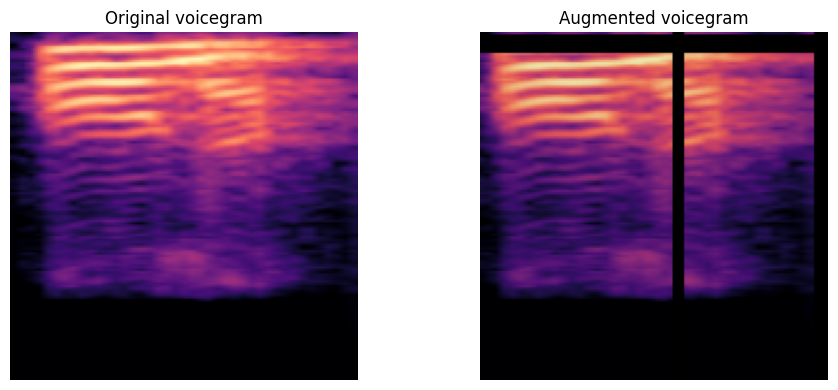

In [35]:
example_arr = np.load(train_df.iloc[0]["spectrogram_path"]).astype(np.float32)
aug_arr = augment_voicegram(example_arr)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(example_arr)
plt.title("Original voicegram")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(aug_arr)
plt.title("Augmented voicegram")
plt.axis("off")

plt.tight_layout()
plt.show()

## 12. Model 1: Baseline CNN

This model is a simple image-classification CNN. It acts as our baseline.

It receives a voicegram image and predicts the command class.

In [36]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes, dropout=0.40):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.15),

            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.20),

            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## 13. Model 2: Proposed Residual-Attention CNN

This is our main contribution.

### Why residual connections?

Residual connections allow information to pass forward more easily. This helps reduce the vanishing-gradient problem in deeper networks.

### Why attention?

Attention helps the model focus on the important time-frequency regions of the voicegram image.

So the proposed model is designed to improve the plain S-CNN architecture mentioned in the research gap.

In [37]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, dropout=0.10):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout2d(dropout)

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        out = F.relu(out + identity, inplace=True)
        return out


class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, hidden, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, channels, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        weights = self.pool(x).view(b, c)
        weights = self.fc(weights).view(b, c, 1, 1)
        return x * weights


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        padding = kernel_size // 2
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        max_value, _ = torch.max(x, dim=1, keepdim=True)
        attention = self.sigmoid(self.conv(torch.cat([avg, max_value], dim=1)))
        return x * attention


class ResidualAttentionCNN(nn.Module):
    def __init__(self, num_classes, dropout=0.45):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )

        self.stage1 = nn.Sequential(
            ResidualBlock(32, 64, stride=2, dropout=0.10),
            ResidualBlock(64, 64, stride=1, dropout=0.10),
        )
        self.attn1 = nn.Sequential(ChannelAttention(64), SpatialAttention())

        self.stage2 = nn.Sequential(
            ResidualBlock(64, 128, stride=2, dropout=0.15),
            ResidualBlock(128, 128, stride=1, dropout=0.15),
        )
        self.attn2 = nn.Sequential(ChannelAttention(128), SpatialAttention())

        self.stage3 = nn.Sequential(
            ResidualBlock(128, 256, stride=2, dropout=0.20),
            ResidualBlock(256, 256, stride=1, dropout=0.20),
        )
        self.attn3 = nn.Sequential(ChannelAttention(256), SpatialAttention())

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.attn1(self.stage1(x))
        x = self.attn2(self.stage2(x))
        x = self.attn3(self.stage3(x))
        x = self.classifier(x)
        return x

## 14. Training and evaluation helper functions

These functions train the models, store the best validation checkpoint, and compute metrics.

In [38]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def make_class_weights(train_dataframe, num_classes):
    counts = train_dataframe["label_idx"].value_counts().reindex(range(num_classes), fill_value=1).values
    weights = counts.sum() / (num_classes * counts)
    return torch.tensor(weights, dtype=torch.float32)


def run_one_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        with torch.set_grad_enabled(is_train):
            logits = model(x)
            loss = criterion(logits, y)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

        preds = logits.argmax(dim=1)
        total_loss += loss.item() * x.size(0)
        total_correct += (preds == y).sum().item()
        total_samples += x.size(0)

    avg_loss = total_loss / max(1, total_samples)
    avg_acc = total_correct / max(1, total_samples)
    return avg_loss, avg_acc


def train_model(model, model_name, train_loader, val_loader, train_dataframe, num_classes):
    model = model.to(DEVICE)
    class_weights = make_class_weights(train_dataframe, num_classes).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=2, factor=0.5)

    best_val_loss = float("inf")
    best_path = MODELS_DIR / f"{model_name}_best.pt"
    patience_counter = 0

    history = {
        "epoch": [],
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    print(f"\nTraining {model_name}")
    print("Trainable parameters:", count_parameters(model))

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = run_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_one_epoch(model, val_loader, criterion, optimizer=None)
        scheduler.step(val_loss)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                "model_state_dict": model.state_dict(),
                "label_to_idx": label_to_idx,
                "idx_to_label": idx_to_label,
                "model_name": model_name,
                "image_size": IMAGE_SIZE,
                "n_mels": N_MELS,
                "target_sample_rate": TARGET_SAMPLE_RATE,
            }, best_path)
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print("Early stopping triggered.")
                break

    # Load best checkpoint back into the model.
    checkpoint = torch.load(best_path, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])

    history_df = pd.DataFrame(history)
    history_df.to_csv(RESULTS_DIR / f"{model_name}_history.csv", index=False)
    return model, history_df, best_path


def get_predictions(model, loader):
    model.eval()
    all_true = []
    all_pred = []
    all_prob = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            logits = model(x)
            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1).cpu().numpy()

            all_true.extend(y.numpy().tolist())
            all_pred.extend(preds.tolist())
            all_prob.extend(probs.cpu().numpy().tolist())

    return np.array(all_true), np.array(all_pred), np.array(all_prob)


def evaluate_model(model, loader, model_name, label_names):
    y_true, y_pred, y_prob = get_predictions(model, loader)

    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    # For isolated word/command classification, WRA is equivalent to overall accuracy.
    word_recognition_accuracy = accuracy

    metrics = {
        "model": model_name,
        "accuracy": accuracy,
        "word_recognition_accuracy": word_recognition_accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
    }

    print(f"\nEvaluation results for {model_name}")
    for key, value in metrics.items():
        if key != "model":
            print(f"{key}: {value:.4f}")

    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))

    cmatrix = confusion_matrix(y_true, y_pred, labels=list(range(len(label_names))))
    return metrics, cmatrix, y_true, y_pred, y_prob

## 15. Train both models

This cell trains:

1. Baseline CNN
2. Proposed Residual-Attention CNN

If training takes too long, reduce `EPOCHS`, `MAX_CLASSES`, or `MAX_SAMPLES_PER_CLASS` in the configuration cell.

In [39]:
num_classes = len(label_names)

baseline_model = BaselineCNN(num_classes=num_classes)
proposed_model = ResidualAttentionCNN(num_classes=num_classes)

baseline_model, baseline_history, baseline_best_path = train_model(
    baseline_model,
    "baseline_cnn",
    train_loader,
    val_loader,
    train_df,
    num_classes,
)

proposed_model, proposed_history, proposed_best_path = train_model(
    proposed_model,
    "proposed_residual_attention_cnn",
    train_loader,
    val_loader,
    train_df,
    num_classes,
)

print("Baseline best checkpoint:", baseline_best_path)
print("Proposed best checkpoint:", proposed_best_path)


Training baseline_cnn
Trainable parameters: 288746
Epoch 01/30 | train_loss=2.3505, train_acc=0.1304 | val_loss=2.3539, val_acc=0.1404
Epoch 02/30 | train_loss=2.2429, train_acc=0.1618 | val_loss=2.3041, val_acc=0.1798


Epoch 03/30 | train_loss=2.1756, train_acc=0.1908 | val_loss=2.0110, val_acc=0.3652
Epoch 04/30 | train_loss=2.0683, train_acc=0.1763 | val_loss=1.8954, val_acc=0.2697
Epoch 05/30 | train_loss=2.0030, train_acc=0.2101 | val_loss=1.8823, val_acc=0.3090
Epoch 06/30 | train_loss=1.9292, train_acc=0.2295 | val_loss=1.9500, val_acc=0.2360
Epoch 07/30 | train_loss=1.8867, train_acc=0.2669 | val_loss=1.9119, val_acc=0.3427
Epoch 08/30 | train_loss=1.8850, train_acc=0.2766 | val_loss=1.7571, val_acc=0.4213
Epoch 09/30 | train_loss=1.8647, train_acc=0.2585 | val_loss=1.7804, val_acc=0.3427
Epoch 10/30 | train_loss=1.8539, train_acc=0.2899 | val_loss=1.8178, val_acc=0.3933
Epoch 11/30 | train_loss=1.8166, train_acc=0.2911 | val_loss=1.7139, val_acc=0.3652
Epoch 12/30 | train_loss=1.8232, train_acc=0.3007 | val_loss=1.6845, val_acc=0.3820
Epoch 13/30 | train_loss=1.7833, train_acc=0.3140 | val_loss=1.6770, val_acc=0.3876
Epoch 14/30 | train_loss=1.7476, train_acc=0.3164 | val_loss=1.6995, val_acc

## 16. Training graphs

These graphs show whether the models are learning properly.

- Training accuracy should generally increase.
- Validation accuracy should also increase.
- If training accuracy is high but validation accuracy is low, the model is overfitting.

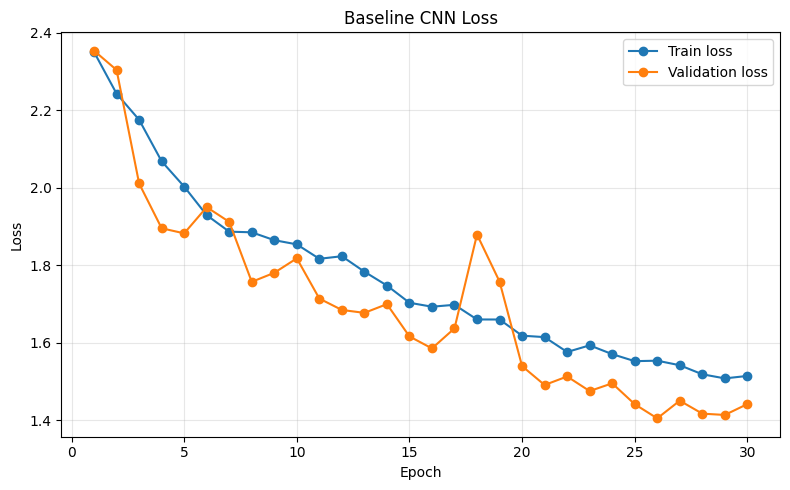

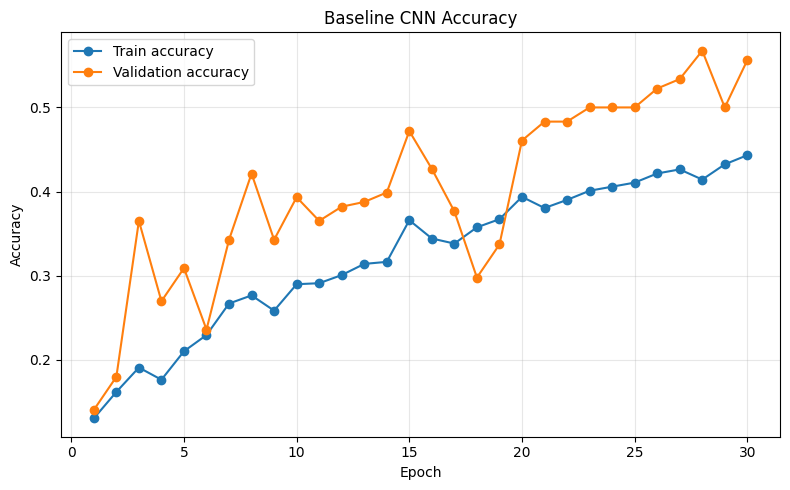

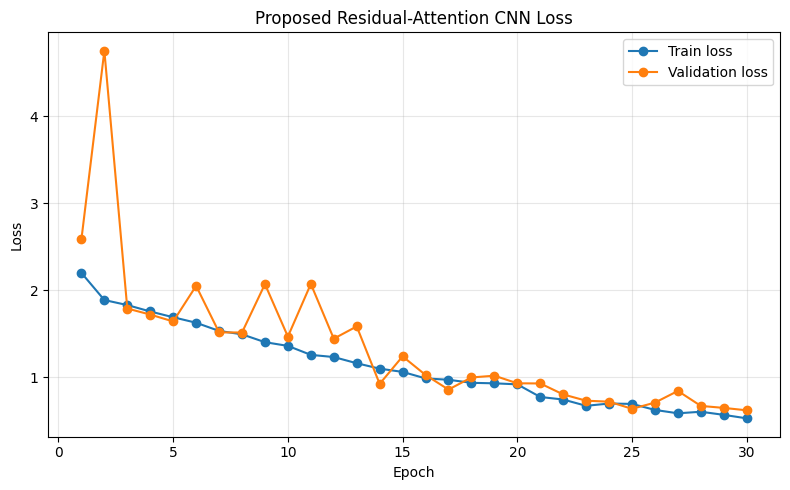

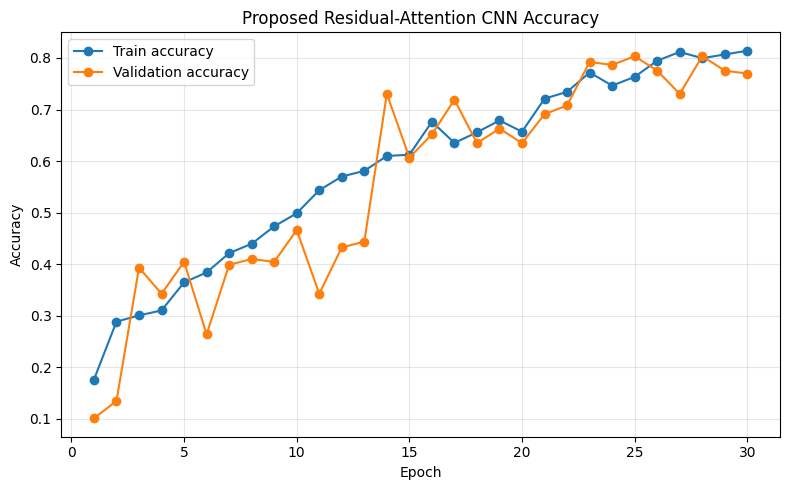

In [40]:
def plot_history(history_df, title_prefix):
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_acc"], marker="o", label="Train accuracy")
    plt.plot(history_df["epoch"], history_df["val_acc"], marker="o", label="Validation accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_history(baseline_history, "Baseline CNN")
plot_history(proposed_history, "Proposed Residual-Attention CNN")

## 17. Test-set evaluation

Now we evaluate both models on unseen test data.

In [41]:
baseline_metrics, baseline_cm, baseline_y_true, baseline_y_pred, baseline_y_prob = evaluate_model(
    baseline_model,
    test_loader,
    "Baseline CNN",
    label_names,
)

proposed_metrics, proposed_cm, proposed_y_true, proposed_y_pred, proposed_y_prob = evaluate_model(
    proposed_model,
    test_loader,
    "Proposed Residual-Attention CNN",
    label_names,
)

comparison_df = pd.DataFrame([baseline_metrics, proposed_metrics])
comparison_df.to_csv(RESULTS_DIR / "model_comparison_metrics.csv", index=False)
comparison_df


Evaluation results for Baseline CNN
accuracy: 0.4381
word_recognition_accuracy: 0.4381
macro_precision: 0.4579
macro_recall: 0.4336
macro_f1: 0.4165

Classification report:
                       precision    recall  f1-score   support

aggiungi_ai_preferiti       0.55      0.55      0.55        20
     chiama_emergenza       0.30      0.40      0.34        20
 chiama_ultimo_numero       0.50      0.16      0.24        19
          deseleziona       0.43      0.16      0.23        19
                   no       0.43      0.86      0.57        21
       nuovo_contatto       0.64      0.35      0.45        20
                 otto       0.41      0.58      0.48        19
                scesi       0.48      0.53      0.50        19
                sette       0.39      0.37      0.38        19
                  uno       0.47      0.39      0.42        18

             accuracy                           0.44       194
            macro avg       0.46      0.43      0.42       194
     

,model,accuracy,word_recognition_accuracy,macro_precision,macro_recall,macro_f1
0,Baseline CNN,0.438144,0.438144,0.457896,0.433551,0.416512
1,Proposed Residual-Attention CNN,0.685567,0.685567,0.703887,0.684515,0.686274


## 18. Model comparison graph

This graph directly compares the baseline and proposed model.

<Figure size 1000x500 with 0 Axes>

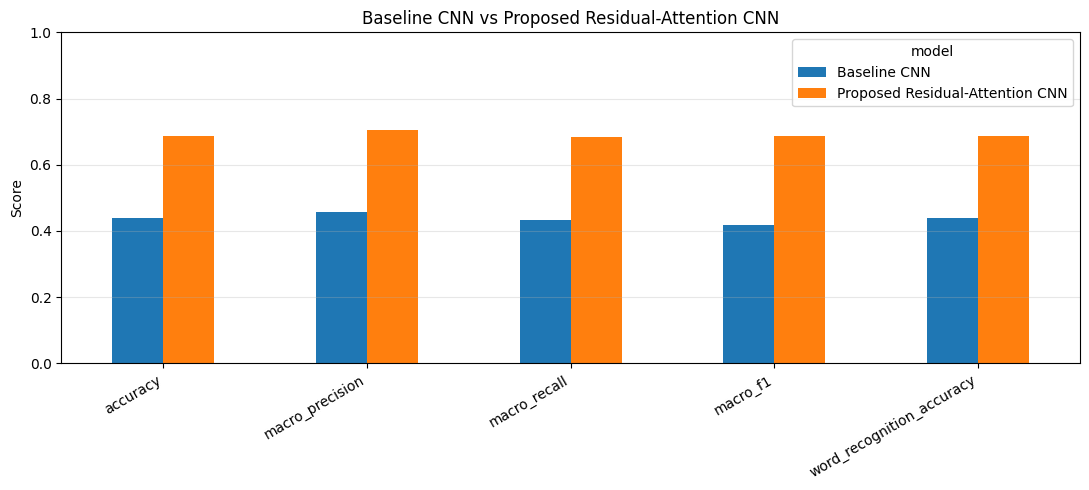

In [42]:
metrics_to_plot = ["accuracy", "macro_precision", "macro_recall", "macro_f1", "word_recognition_accuracy"]
plot_df = comparison_df.set_index("model")[metrics_to_plot]

plt.figure(figsize=(10, 5))
plot_df.T.plot(kind="bar", figsize=(11, 5))
plt.title("Baseline CNN vs Proposed Residual-Attention CNN")
plt.ylabel("Score")
plt.ylim(0, 1.0)
plt.xticks(rotation=30, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Severity-wise comparison:


,model,severity,samples,unique_speakers,accuracy,word_recognition_accuracy,macro_precision,macro_recall,macro_f1
0,Baseline CNN,0,88,4,0.500000,0.500000,0.571155,0.494444,0.471469
1,Baseline CNN,1,43,2,0.441860,0.441860,0.340714,0.440000,0.371284
2,Baseline CNN,3,63,3,0.349206,0.349206,0.318398,0.335714,0.300814
3,Proposed Residual-Attention CNN,0,88,4,0.829545,0.829545,0.895597,0.828889,0.837771
4,Proposed Residual-Attention CNN,1,43,2,0.674419,0.674419,0.717540,0.680000,0.663919
5,Proposed Residual-Attention CNN,3,63,3,0.492063,0.492063,0.478611,0.488095,0.476529


<Figure size 1000x500 with 0 Axes>

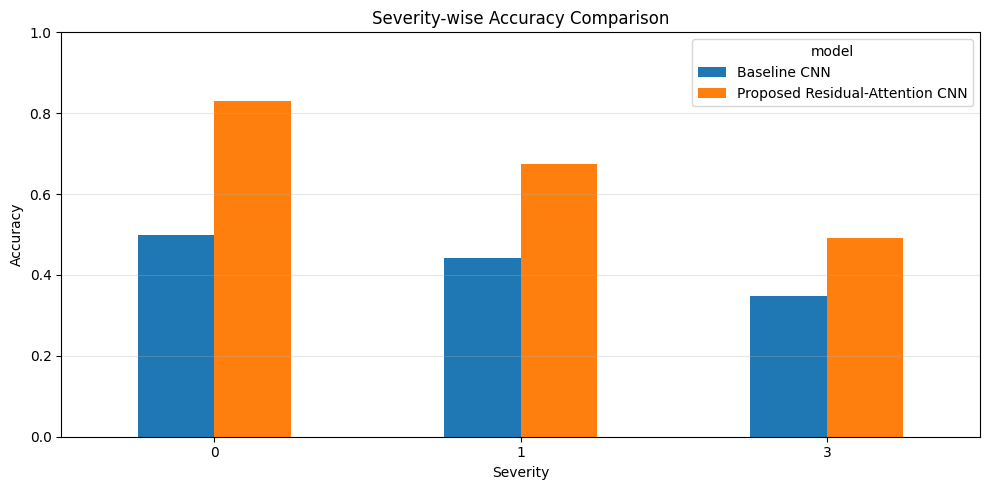

<Figure size 1000x500 with 0 Axes>

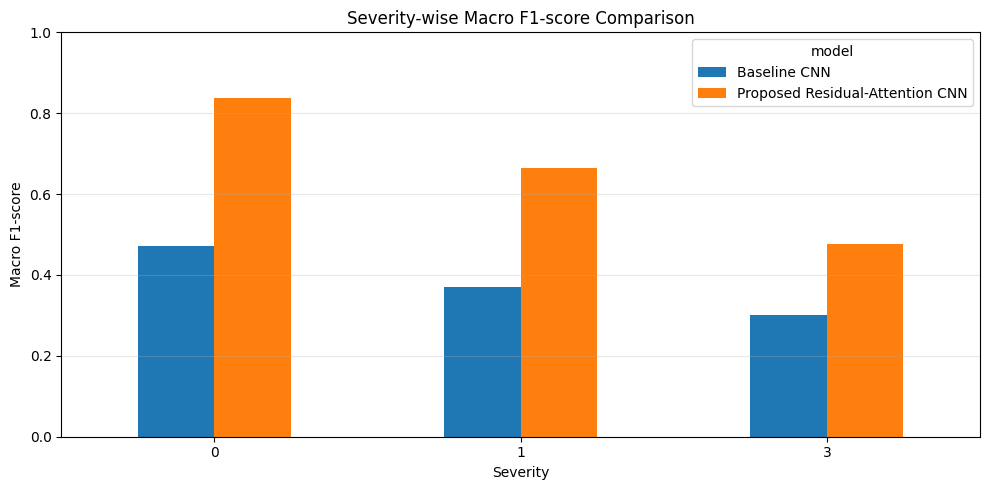

In [43]:
def severity_wise_evaluation(test_dataframe, y_true, y_pred, model_name):
    """
    Evaluate model performance separately for each dysarthria severity group.
    """
    eval_df = test_dataframe.reset_index(drop=True).copy()

    if len(eval_df) != len(y_true):
        raise ValueError(
            f"Length mismatch: test dataframe has {len(eval_df)} rows, "
            f"but predictions have {len(y_true)} rows."
        )

    eval_df["true_idx"] = y_true
    eval_df["pred_idx"] = y_pred
    eval_df["true_label"] = eval_df["true_idx"].map(idx_to_label)
    eval_df["pred_label"] = eval_df["pred_idx"].map(idx_to_label)
    eval_df["correct"] = eval_df["true_idx"] == eval_df["pred_idx"]

    rows = []

    for severity_value, group in eval_df.groupby("severity"):
        group_true = group["true_idx"].to_numpy()
        group_pred = group["pred_idx"].to_numpy()

        accuracy = accuracy_score(group_true, group_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(
            group_true,
            group_pred,
            average="macro",
            zero_division=0,
        )

        rows.append({
            "model": model_name,
            "severity": severity_value,
            "samples": len(group),
            "unique_speakers": group["speaker_id"].nunique(),
            "accuracy": accuracy,
            "word_recognition_accuracy": accuracy,
            "macro_precision": precision,
            "macro_recall": recall,
            "macro_f1": f1,
        })

    return pd.DataFrame(rows).sort_values(["severity", "model"]).reset_index(drop=True)


baseline_severity_df = severity_wise_evaluation(
    test_df,
    baseline_y_true,
    baseline_y_pred,
    "Baseline CNN",
)

proposed_severity_df = severity_wise_evaluation(
    test_df,
    proposed_y_true,
    proposed_y_pred,
    "Proposed Residual-Attention CNN",
)

severity_comparison_df = pd.concat(
    [baseline_severity_df, proposed_severity_df],
    ignore_index=True,
)

severity_comparison_df.to_csv(
    RESULTS_DIR / "severity_wise_model_comparison.csv",
    index=False,
)

print("Severity-wise comparison:")
display(severity_comparison_df)

plt.figure(figsize=(10, 5))
severity_accuracy_pivot = severity_comparison_df.pivot(
    index="severity",
    columns="model",
    values="accuracy",
)

severity_accuracy_pivot.plot(kind="bar", figsize=(10, 5))
plt.title("Severity-wise Accuracy Comparison")
plt.xlabel("Severity")
plt.ylabel("Accuracy")
plt.ylim(0, 1.0)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
severity_f1_pivot = severity_comparison_df.pivot(
    index="severity",
    columns="model",
    values="macro_f1",
)

severity_f1_pivot.plot(kind="bar", figsize=(10, 5))
plt.title("Severity-wise Macro F1-score Comparison")
plt.xlabel("Severity")
plt.ylabel("Macro F1-score")
plt.ylim(0, 1.0)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 19. Confusion matrices

A confusion matrix shows which commands are being confused with other commands.

Rows = true labels.  
Columns = predicted labels.

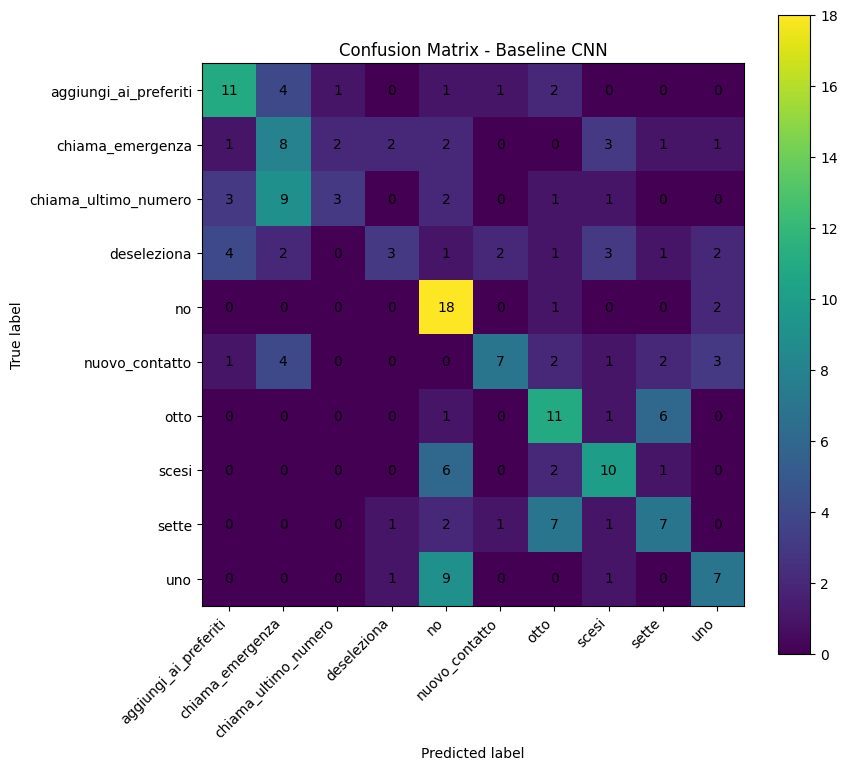

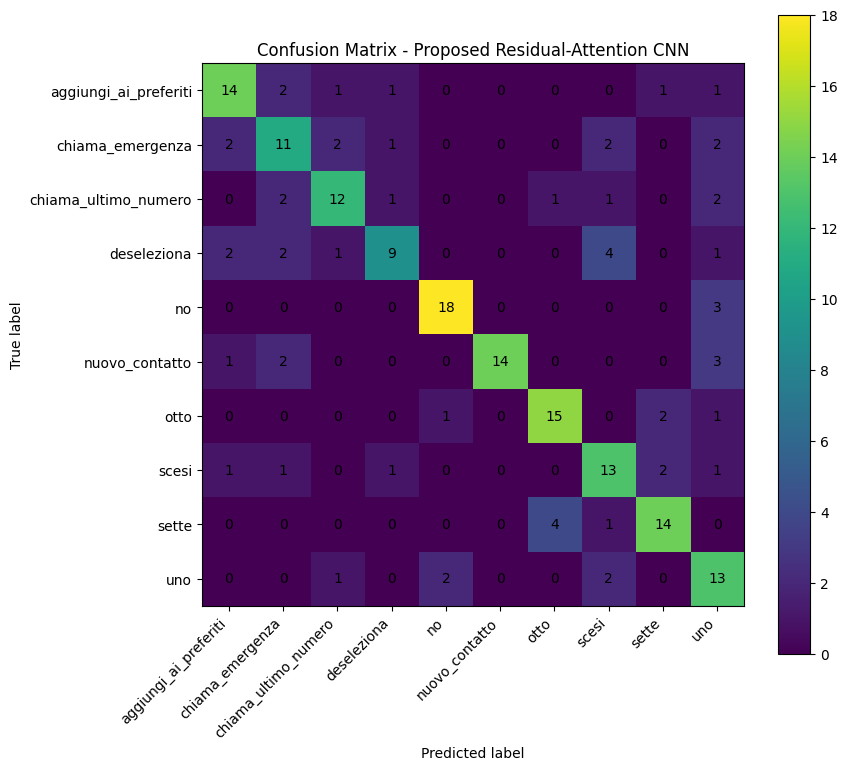

In [44]:
def plot_confusion_matrix(cmatrix, labels, title):
    plt.figure(figsize=(9, 8))
    plt.imshow(cmatrix, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=45, ha="right")
    plt.yticks(tick_marks, labels)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")

    threshold = cmatrix.max() / 2 if cmatrix.max() > 0 else 0
    for i in range(cmatrix.shape[0]):
        for j in range(cmatrix.shape[1]):
            value = cmatrix[i, j]
            plt.text(j, i, str(value), ha="center", va="center")

    plt.tight_layout()
    plt.show()

plot_confusion_matrix(baseline_cm, label_names, "Confusion Matrix - Baseline CNN")
plot_confusion_matrix(proposed_cm, label_names, "Confusion Matrix - Proposed Residual-Attention CNN")

## 20. Correct and wrong prediction examples

This helps explain what the model learned and where it still fails.

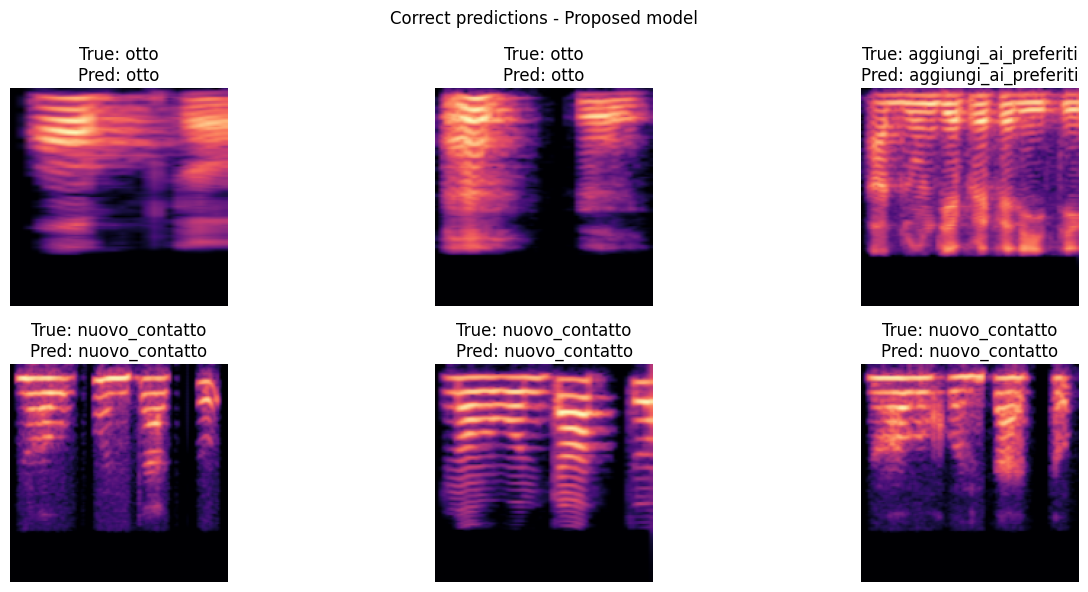

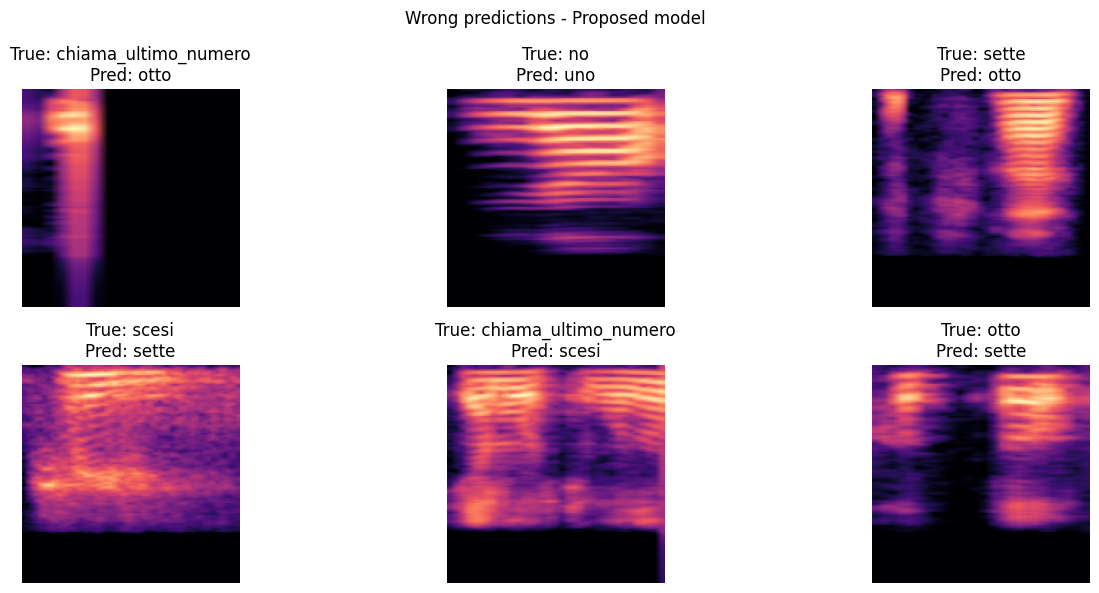

In [45]:
def show_prediction_examples(test_dataframe, y_true, y_pred, title, max_examples=6, show_correct=True):
    indices = np.where((y_true == y_pred) if show_correct else (y_true != y_pred))[0]
    if len(indices) == 0:
        print("No examples found for:", title)
        return

    indices = indices[:max_examples]
    plt.figure(figsize=(14, 6))
    for plot_idx, data_idx in enumerate(indices, start=1):
        row = test_dataframe.iloc[data_idx]
        arr = np.load(row["spectrogram_path"])
        true_label = idx_to_label[int(y_true[data_idx])]
        pred_label = idx_to_label[int(y_pred[data_idx])]

        plt.subplot(2, math.ceil(max_examples / 2), plot_idx)
        plt.imshow(arr)
        plt.title(f"True: {true_label}\nPred: {pred_label}")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_prediction_examples(test_df, proposed_y_true, proposed_y_pred, "Correct predictions - Proposed model", show_correct=True)
show_prediction_examples(test_df, proposed_y_true, proposed_y_pred, "Wrong predictions - Proposed model", show_correct=False)

## 21. Single-audio prediction function

This function takes one audio file, converts it into a voicegram, and predicts the command.

In [46]:
def predict_audio_file(audio_path, model, top_k=3):
    model.eval()
    arr = audio_to_voicegram_array(audio_path)
    x = torch.tensor(np.ascontiguousarray(arr.transpose(2, 0, 1)), dtype=torch.float32)
    x = x.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    top_indices = probs.argsort()[::-1][:top_k]
    results = []
    for idx in top_indices:
        results.append({
            "label": idx_to_label[int(idx)],
            "confidence": float(probs[idx]),
        })
    return pd.DataFrame(results)

# Demo prediction on one test audio file
example_test_audio = test_df.iloc[0]["audio_path"]
print("Audio path:", example_test_audio)
predict_audio_file(example_test_audio, proposed_model, top_k=3)

Audio path: easycall_voicegram_project_workspace/raw_audio/audio/chiama_ultimo_numero/easycall_fc07_chiama_ultimo_numero_00000.wav


,label,confidence
0,otto,0.490551
1,sette,0.428091
2,no,0.045734


## 22. Final project conclusion

### What we implemented

This notebook implemented an end-to-end dysarthric command-recognition system using the Speech Vision idea.

The system converted speech audio into visual Mel-spectrogram/voicegram-like images and trained two models:

1. **Baseline CNN**
2. **Proposed Residual-Attention CNN**

### Research gap addressed

The original Speech Vision paper mentioned that its S-CNN architecture could be improved to reduce vanishing-gradient issues and representational bottlenecks. This project addressed that gap by adding:

- Residual connections
- Channel attention
- Spatial attention
- Stronger spectrogram augmentation

### Metrics used

The notebook reports:

- Accuracy
- Word Recognition Accuracy
- Macro Precision
- Macro Recall
- Macro F1-score
- Classification report
- Confusion matrix
- Training and validation graphs

### Final claim

If the proposed model achieves better validation/test scores than the baseline model, then the project supports the claim that residual-attention learning can improve voicegram-based dysarthric command recognition under limited-data conditions.

If the proposed model does not outperform the baseline, that is still a valid research outcome. In that case, the conclusion should say that the heavier architecture may require more data, better tuning, or longer training.

## 23. Suggested report-ready summary

You can use this in your project report or presentation.

> This project extends the Speech Vision approach for dysarthric automatic speech recognition by converting command speech into voicegram-like Mel-spectrogram images and classifying them using deep learning. The baseline system uses a conventional convolutional neural network, while the proposed system introduces residual learning and attention mechanisms to reduce vanishing-gradient effects and improve feature selection. The model is evaluated on the EasyCall dysarthric command-speech dataset using accuracy, Word Recognition Accuracy, precision, recall, F1-score, and confusion matrix analysis.